In [1]:
print('Hello World')

Hello World


In [1]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [6]:
GEMINI_API_KEY=os.getenv("GEMINI_API_KEY")

In [ ]:
if not GEMINI_API_KEY:
    raise ValueError("GEMINI_API_KEY is not set in the environment variables.")
os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI

chat_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

In [5]:
chat_llm.invoke("Hello,How are you?").content

"Hello! I'm doing very well, thank you for asking.\n\nHow are you today?"

In [8]:
from typing_extensions import TypedDict,Annotated
import operator
from langchain_core.messages import AnyMessage,HumanMessage,AIMessage

In [9]:
class GraphState(TypedDict):
    messages:Annotated[list[AnyMessage],operator.add]

In [ ]:
{
    "messages": [HumanMessage(content="Hi, this is Sunny. Say hello in detail.")]
}


In [ ]:
["hi"]

In [ ]:
["hi","how are you?"]

In [10]:
def llm_call(state: GraphState) -> dict:
    """Call the LLM using conversation messages and append AI response."""
    response = chat_llm.invoke(state["messages"])  # AIMessage
    return {
        "messages": [response]
    }

In [11]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message."""
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }

In [12]:
from langgraph.graph import StateGraph

In [13]:
builder = StateGraph(GraphState)

In [14]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [15]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [16]:
app = builder.compile()

In [17]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [18]:
from IPython.display import Image, display

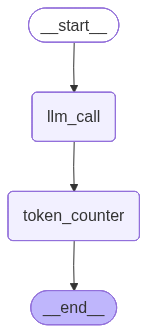

In [22]:
display(Image(app.get_graph().draw_mermaid_png()))

In [23]:
result = app.invoke({
    "messages": [HumanMessage(content="Hi, this is varshitha. Say hello in detail.")]
})

In [24]:
for m in result["messages"]:
    print(type(m).__name__, ":", m.content)

HumanMessage : Hi, this is varshitha. Say hello in detail.
AIMessage : Well hello there, Varshitha!

It's absolutely wonderful to connect with you. I'm here and ready to assist you in any way I can. Please feel free to share whatever you have in mind or whatever you'd like to discuss.

Looking forward to our interaction!
AIMessage : Total token number in the generated answer (word count) is 44


In [25]:
chat_llm

ChatGoogleGenerativeAI(output_version=None, profile={'name': 'Gemini 2.5 Flash', 'release_date': '2025-03-20', 'last_updated': '2025-06-05', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-2.5-flash', temperature=0.0, client=<google.genai.client.Client object at 0x785a2ab08290>, default_metadata=(), model_kwargs={})